In [1]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
from time import sleep
import json
import os
import pandas as pd

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

In [2]:
type(data)

dict

In [3]:
#This allows you to see all the columns, not just like 15

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
#This normalizes the data and makes it pretty in a dataframe

df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.002555e+07,2.002555e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12624,1,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,1.633184e+12,"[mineable, pow, sha-256, store-of-value, state...",81555.030937,4.383457e+10,4.378895e+10,4.561431e+07,12.5934,-0.033180,0.500819,7.615937,16.426716,20.265005,19.933094,1.633184e+12,60.5237,1.712656e+12,None,2026-05-06T16:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
1,1027,Ethereum,ETH,ethereum,True,1.206872e+08,1.206872e+08,NaN,2015-08-07T00:00:00.000Z,11920,2,2026-05-06T16:37:00.000Z,None,NaN,NaN,NaN,2.842191e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2355.005919,2.258377e+10,2.243636e+10,1.474095e+08,34.4537,-0.124837,-0.748866,4.012351,8.886116,19.071794,18.841204,2.842191e+11,10.5328,2.842191e+11,None,2026-05-06T16:37:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
2,825,Tether USDt,USDT,tether,True,1.895742e+11,1.942035e+11,NaN,2015-02-25T00:00:00.000Z,180492,3,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,1.941705e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999830,1.478832e+11,1.461198e+11,1.763393e+09,16.7128,0.003105,-0.008758,0.010353,0.004233,-0.010958,0.162589,1.895420e+11,7.0241,1.941705e+11,None,2026-05-06T16:38:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-06 12:40:14.438802
3,52,XRP,XRP,xrp,False,6.179623e+10,9.998567e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1830,4,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,1.425752e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.425957,3.026723e+09,3.025243e+09,1.479839e+06,60.6678,-0.134126,1.202286,4.704914,5.631386,4.946441,10.207570,8.811874e+10,3.2656,1.425957e+11,None,2026-05-06T16:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
4,1839,BNB,BNB,bnb,False,1.347858e+08,1.347858e+08,1.347858e+08,2017-07-25T00:00:00.000Z,3217,5,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,8.719393e+10,"[marketplace, centralized-exchange, payments, ...",646.907261,2.544632e+09,2.526871e+09,1.776078e+07,56.3237,-0.264358,2.648463,4.882564,6.439859,3.778469,-2.964674,8.719393e+10,3.2313,8.719393e+10,None,2026-05-06T16:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
5,3408,USDC,USDC,usd-coin,False,7.822160e+10,7.822160e+10,NaN,2018-10-08T00:00:00.000Z,39289,6,2026-05-06T16:38:00.000Z,None,NaN,6.090122e+10,6.088996e+10,7.820714e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999815,6.184692e+10,5.967717e+10,2.169756e+09,5.0968,0.003753,0.001314,-0.005307,0.008503,-0.013025,-0.014706,7.820714e+10,2.8982,7.820714e+10,None,2026-05-06T16:38:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-06 12:40:14.438802
6,5426,Solana,SOL,solana,True,5.764602e+08,6.258328e+08,NaN,2020-04-10T00:00:00.000Z,1126,7,2026-05-06T16:37:00.000Z,None,NaN,5.252369e+08,4.663479e+10,5.556652e+10,"[pos, platform, solana-ecosystem, cms-holdings...",88.788117,5.903739e+09,5.903719e+09,1.990002e+04,47.9574,0.062955,4.047949,6.839462,8.211042,6.173128,4.029649,5.118281e+10,1.8965,5.556652e+10,None,2026-05-06T16:37:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
7,1958,TRON,TRX,tron,True,9.479252e+10,9.479252e+10,NaN,2017-09-13T00:00:00.000Z,1338,8,2026-05-06T16:39:00.000Z,None,NaN,9.466789e+10,3.2

In [5]:
def api_runner():
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
        'start': '1',
        'limit': '15',
        'convert': 'USD'
    }
    headers = {
        'Accepts': 'application/json',
        'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
    }

    session = Session()
    session.headers.update(headers)

    try:
        response = session.get(url, params=parameters)
        data = json.loads(response.text)

        df = pd.json_normalize(data['data'])
        df['timestamp'] = pd.to_datetime('now')

        file_path = r'C:\Users\Tina McKenney\Documents\Python\Python Scripts\API.csv'

        print("Writing to CSV...")  #debug

        if not os.path.isfile(file_path):
            df.to_csv(file_path, index=False)
            print("File created!")
        else:
            df.to_csv(file_path, mode='a', header=False, index=False)
            print("File appended!")

    except (ConnectionError, Timeout, TooManyRedirects) as e:
        print(e)

#NOTE:
    # Use this if you just want to keep it in a dataframe
    #df2 = pd.json_normalize(data['data'])
    #df2['Timestamp'] = pd.to_datetime('now')
    #df = pd.concat([df, df2], ignore_index=True)
       
    #Then to read in the file: df = pd.read_csv(r'C:\Users\Tina McKenney\Documents\Python\Python Scripts\API.csv')

In [6]:
for i in range(333):
    api_runner()
    print('API Runner completed')
    sleep(60) #sleep for 1 minute
exit()

Writing to CSV...
File appended!
API Runner completed
Writing to CSV...
File appended!
API Runner completed
Writing to CSV...
File appended!
API Runner completed
Writing to CSV...
File appended!
API Runner completed
Writing to CSV...
File appended!
API Runner completed


KeyboardInterrupt: 

In [7]:
df72 = pd.read_csv(r'C:\Users\Tina McKenney\Documents\Python\Python Scripts\API.csv')
df72

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.002551e+07,2.002551e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12624,1,2026-05-06T14:59:00.000Z,NaN,NaN,NaN,NaN,1.632060e+12,"['mineable', 'pow', 'sha-256', 'store-of-value...",81499.042705,4.363186e+10,4.359360e+10,3.825495e+07,1.1640,-0.244504,0.187893,6.471032,17.020232,19.815998,17.554639,1.632060e+12,60.3911,1.711480e+12,NaN,2026-05-06T14:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 11:01:34.564973
1,1027,Ethereum,ETH,ethereum,True,1.206872e+08,1.206872e+08,NaN,2015-08-07T00:00:00.000Z,11920,2,2026-05-06T14:59:00.000Z,NaN,NaN,NaN,NaN,2.845675e+11,"['pos', 'smart-contracts', 'ethereum-ecosystem...",2357.892794,2.195513e+10,2.181432e+10,1.408137e+08,16.9227,-0.518016,-0.893396,2.543604,9.309566,18.657376,15.320085,2.845675e+11,10.5299,2.845675e+11,NaN,2026-05-06T14:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 11:01:34.564973
2,825,Tether USDt,USDT,tether,True,1.895742e+11,1.942035e+11,NaN,2015-02-25T00:00:00.000Z,180463,3,2026-05-06T14:59:00.000Z,NaN,NaN,NaN,NaN,1.941372e+11,"['stablecoin', 'asset-backed-stablecoin', 'usd...",0.999659,1.480755e+11,1.462952e+11,1.780283e+09,12.3625,-0.018142,-0.026534,-0.008311,-0.028555,-0.029592,0.120467,1.895095e+11,7.0092,1.941372e+11,NaN,2026-05-06T14:59:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-06 11:01:34.564973
3,52,XRP,XRP,xrp,False,6.179623e+10,9.998567e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1830,4,2026-05-06T14:59:00.000Z,NaN,NaN,NaN,NaN,1.424505e+11,"['medium-of-exchange', 'enterprise-solutions',...",1.424709,2.963656e+09,2.962291e+09,1.364916e+06,45.2324,0.105075,1.035183,3.770461,5.816334,4.411828,4.728606,8.804164e+10,3.2578,1.424709e+11,NaN,2026-05-06T14:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 11:01:34.564973
4,1839,BNB,BNB,bnb,False,1.347858e+08,1.347858e+08,1.347858e+08,2017-07-25T00:00:00.000Z,3217,5,2026-05-06T14:59:00.000Z,NaN,NaN,NaN,NaN,8.730926e+10,"['marketplace', 'centralized-exchange', 'payme...",647.762902,2.529427e+09,2.512122e+09,1.730505e+07,46.8848,0.110612,2.771554,4.244468,6.755160,3.239887,-4.235423,8.730926e+10,3.2307,8.730926e+10,NaN,2026-05-06T14:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 11:01:34.564973
5,3408,USDC,USDC,usd-coin,False,7.817049e+10,7.817049e+10,NaN,2018-10-08T00:00:00.000Z,39287,6,2026-05-06T14:59:00.000Z,NaN,NaN,6.090122e+10,6.088059e+10,7.814400e+10,"['medium-of-exchange', 'stablecoin', 'asset-ba...",0.999661,6.305723e+10,6.090656e+10,2.150673e+09,7.4166,-0.015346,-0.019905,-0.006959,-0.023820,-0.028903,-0.008659,7.814400e+10,2.8902,7.814400e+10,NaN,2026-05-06T14:59:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-06 11:01:34.564973
6,5426,Solana,SOL,solana,True,5.764602e+08,6.258329e+08,NaN,2020-04-10T00:00:00.000Z,1126,7,2026-05-06T14:59:00.000Z,NaN,NaN,5.252369e+08,4.643153e+10,5.532433e+10,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",88.401121,5.842762e+09,5.842742e+09,1.943965e+04,36.0659,0.124104,3.475680,5.432912,7.555918,4.923047,-0.445828,5.095973e+10,1.8852,5.532433e+10,NaN,2026-05-06T14:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 11:01:34.564973
7,1958,TRON,TRX,tron,True,9.479270e+10,9.479271e+10,NaN,2017-09-13T00:00:00.000Z,1338,8,2026-05-06T15:00:00.000Z,NaN,NaN,9.466789e+10,3.255482e+10,3.

In [8]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.002555e+07,2.002555e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12624,1,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,1.633184e+12,"[mineable, pow, sha-256, store-of-value, state...",81555.030937,4.383457e+10,4.378895e+10,4.561431e+07,12.5934,-0.033180,0.500819,7.615937,16.426716,20.265005,19.933094,1.633184e+12,60.5237,1.712656e+12,None,2026-05-06T16:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
1,1027,Ethereum,ETH,ethereum,True,1.206872e+08,1.206872e+08,NaN,2015-08-07T00:00:00.000Z,11920,2,2026-05-06T16:37:00.000Z,None,NaN,NaN,NaN,2.842191e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2355.005919,2.258377e+10,2.243636e+10,1.474095e+08,34.4537,-0.124837,-0.748866,4.012351,8.886116,19.071794,18.841204,2.842191e+11,10.5328,2.842191e+11,None,2026-05-06T16:37:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
2,825,Tether USDt,USDT,tether,True,1.895742e+11,1.942035e+11,NaN,2015-02-25T00:00:00.000Z,180492,3,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,1.941705e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999830,1.478832e+11,1.461198e+11,1.763393e+09,16.7128,0.003105,-0.008758,0.010353,0.004233,-0.010958,0.162589,1.895420e+11,7.0241,1.941705e+11,None,2026-05-06T16:38:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-06 12:40:14.438802
3,52,XRP,XRP,xrp,False,6.179623e+10,9.998567e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1830,4,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,1.425752e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.425957,3.026723e+09,3.025243e+09,1.479839e+06,60.6678,-0.134126,1.202286,4.704914,5.631386,4.946441,10.207570,8.811874e+10,3.2656,1.425957e+11,None,2026-05-06T16:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
4,1839,BNB,BNB,bnb,False,1.347858e+08,1.347858e+08,1.347858e+08,2017-07-25T00:00:00.000Z,3217,5,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,8.719393e+10,"[marketplace, centralized-exchange, payments, ...",646.907261,2.544632e+09,2.526871e+09,1.776078e+07,56.3237,-0.264358,2.648463,4.882564,6.439859,3.778469,-2.964674,8.719393e+10,3.2313,8.719393e+10,None,2026-05-06T16:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
5,3408,USDC,USDC,usd-coin,False,7.822160e+10,7.822160e+10,NaN,2018-10-08T00:00:00.000Z,39289,6,2026-05-06T16:38:00.000Z,None,NaN,6.090122e+10,6.088996e+10,7.820714e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999815,6.184692e+10,5.967717e+10,2.169756e+09,5.0968,0.003753,0.001314,-0.005307,0.008503,-0.013025,-0.014706,7.820714e+10,2.8982,7.820714e+10,None,2026-05-06T16:38:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-06 12:40:14.438802
6,5426,Solana,SOL,solana,True,5.764602e+08,6.258328e+08,NaN,2020-04-10T00:00:00.000Z,1126,7,2026-05-06T16:37:00.000Z,None,NaN,5.252369e+08,4.663479e+10,5.556652e+10,"[pos, platform, solana-ecosystem, cms-holdings...",88.788117,5.903739e+09,5.903719e+09,1.990002e+04,47.9574,0.062955,4.047949,6.839462,8.211042,6.173128,4.029649,5.118281e+10,1.8965,5.556652e+10,None,2026-05-06T16:37:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
7,1958,TRON,TRX,tron,True,9.479252e+10,9.479252e+10,NaN,2017-09-13T00:00:00.000Z,1338,8,2026-05-06T16:39:00.000Z,None,NaN,9.466789e+10,3.2

In [9]:
# Convert the scientific notation to just numbers

pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [10]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20025546.00000,20025546.00000,21000000.00000,2010-07-13T00:00:00.000Z,12624,1,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,1633184023558.42993,"[mineable, pow, sha-256, store-of-value, state...",81555.03094,43834566903.86902,43788952589.47581,45614314.39322,12.59340,-0.03318,0.50082,7.61594,16.42672,20.26500,19.93309,1633184023558.43164,60.52370,1712655649675.02002,None,2026-05-06T16:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
1,1027,Ethereum,ETH,ethereum,True,120687222.38365,120687222.38365,NaN,2015-08-07T00:00:00.000Z,11920,2,2026-05-06T16:37:00.000Z,None,NaN,NaN,NaN,284219123019.96002,"[pos, smart-contracts, ethereum-ecosystem, coi...",2355.00592,22583772130.85468,22436362612.26880,147409518.58588,34.45370,-0.12484,-0.74887,4.01235,8.88612,19.07179,18.84120,284219123019.95892,10.53280,284219123019.96002,None,2026-05-06T16:37:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
2,825,Tether USDt,USDT,tether,True,189574168695.52786,194203497628.38724,NaN,2015-02-25T00:00:00.000Z,180492,3,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,194170542526.12000,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99983,147883209518.71072,146119816897.78296,1763392620.92742,16.71280,0.00310,-0.00876,0.01035,0.00423,-0.01096,0.16259,189541999161.03207,7.02410,194170542526.12000,None,2026-05-06T16:38:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-06 12:40:14.438802
3,52,XRP,XRP,xrp,False,61796225236.00000,99985670046.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1830,4,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,142575238850.82001,"[medium-of-exchange, enterprise-solutions, xrp...",1.42596,3026722867.51574,3025243028.63027,1479838.88547,60.66780,-0.13413,1.20229,4.70491,5.63139,4.94644,10.20757,88118743106.36891,3.26560,142595672745.13000,None,2026-05-06T16:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
4,1839,BNB,BNB,bnb,False,134785832.27000,134785832.27000,134785832.27000,2017-07-25T00:00:00.000Z,3217,5,2026-05-06T16:38:00.000Z,None,NaN,NaN,NaN,87193933603.38000,"[marketplace, centralized-exchange, payments, ...",646.90726,2544632008.27005,2526871227.74229,17760780.52776,56.32370,-0.26436,2.64846,4.88256,6.43986,3.77847,-2.96467,87193933603.37590,3.23130,87193933603.38000,None,2026-05-06T16:38:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-06 12:40:14.438802
5,3408,USDC,USDC,usd-coin,False,78221599365.06570,78221599365.06570,NaN,2018-10-08T00:00:00.000Z,39289,6,2026-05-06T16:38:00.000Z,None,NaN,60901219650.23000,60889964924.26395,78207143781.57001,"[medium-of-exchange, stablecoin, asset-backed-...",0.99982,61846924301.25288,59677168627.14864,2169755674.10419,5.09680,0.00375,0.00131,-0.00531,0.00850,-0.01303,-0.01471,78207143781.57269,2.89820,78207143781.57001,None,2026-05-06T16:38:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-06 12:40:14.438802
6,5426,Solana,SOL,solana,True,576460172.57099,625832844.68544,NaN,2020-04-10T00:00:00.000Z,1126,7,2026-05-06T16:37:00.000Z,None,NaN,525236893.30000,46634794685.14731,55566519776.93000,"[pos, platform, solana-ecosystem, cms-holdings...",88.78812,5903738613.68974,5903718713.67193,19900.01782,47.95740,0.06296,4.04795,6.83946,8.21104,6.17313,4.02965,511

In [11]:
# look at the coin trends over time

df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.03318,0.50082,7.61594,16.42672,20.26500,19.93309
Ethereum,-0.12484,-0.74887,4.01235,8.88612,19.07179,18.84120
Tether USDt,0.00310,-0.00876,0.01035,0.00423,-0.01096,0.16259
XRP,-0.13413,1.20229,4.70491,5.63139,4.94644,10.20757
BNB,-0.26436,2.64846,4.88256,6.43986,3.77847,-2.96467
USDC,0.00375,0.00131,-0.00531,0.00850,-0.01303,-0.01471
Solana,0.06296,4.04795,6.83946,8.21104,6.17313,4.02965
TRON,0.65803,0.92468,7.21265,9.36276,21.42157,24.71917
Dogecoin,-0.29095,0.61286,10.23617,21.80471,25.21677,19.08257


In [12]:
#Change layout - pivot/unpivot
df4 = df3.stack()
df4

name                                      
Bitcoin       quote.USD.percent_change_1h     -0.03318
              quote.USD.percent_change_24h     0.50082
              quote.USD.percent_change_7d      7.61594
              quote.USD.percent_change_30d    16.42672
              quote.USD.percent_change_60d    20.26500
              quote.USD.percent_change_90d    19.93309
Ethereum      quote.USD.percent_change_1h     -0.12484
              quote.USD.percent_change_24h    -0.74887
              quote.USD.percent_change_7d      4.01235
              quote.USD.percent_change_30d     8.88612
              quote.USD.percent_change_60d    19.07179
              quote.USD.percent_change_90d    18.84120
Tether USDt   quote.USD.percent_change_1h      0.00310
              quote.USD.percent_change_24h    -0.00876
              quote.USD.percent_change_7d      0.01035
              quote.USD.percent_change_30d     0.00423
              quote.USD.percent_change_60d    -0.01096
              quote.US

In [13]:
type(df4)

pandas.core.series.Series

In [14]:
df5 = df4.to_frame(name='values')
df5

values
name                                               
Bitcoin      quote.USD.percent_change_1h   -0.03318
             quote.USD.percent_change_24h   0.50082
             quote.USD.percent_change_7d    7.61594
             quote.USD.percent_change_30d  16.42672
             quote.USD.percent_change_60d  20.26500
             quote.USD.percent_change_90d  19.93309
Ethereum     quote.USD.percent_change_1h   -0.12484
             quote.USD.percent_change_24h  -0.74887
             quote.USD.percent_change_7d    4.01235
             quote.USD.percent_change_30d   8.88612
             quote.USD.percent_change_60d  19.07179
             quote.USD.percent_change_90d  18.84120
Tether USDt  quote.USD.percent_change_1h    0.00310
             quote.USD.percent_change_24h  -0.00876
             quote.USD.percent_change_7d    0.01035
             quote.USD.percent_change_30d   0.00423
             quote.USD.percent_change_60d  -0.01096
             quote.USD.percent_change_90d   0.16259
XRP          quote.USD.percent_change_1h   -0.13413
             quote.USD.percent_change_24h   1.20229
             quote.USD.percent_change_7d    4.70491
             quote.USD.percent_change_30d   5.63139
             quote.USD.percent_change_60d   4.94644
             quote.USD.percent_change_90d  10.20757
BNB          quote.USD.percent_change_1h   -0.26436
             quote.USD.percent_change_24h   2.64846
             quote.USD.percent_change_7d    4.88256
             quote.USD.percent_change_30d   6.43986
             quote.USD.percent_change_60d   3.77847
             quote.USD.percent_change_90d  -2.96467
USDC         quote.USD.percent_change_1h    0.00375
             quote.USD.percent_change_24h   0.00131
             quote.USD.percent_change_7d   -0.00531
             quote.USD.percent_change_30d   0.00850
             quote.USD.percent_change_60d  -0.01303
             quote.USD.percent_change_90d  -0.01471
Solana       quote.USD.percent_change_1h    0.06296
             quote.USD.percent_change_24h   4.04795
             quote.USD.percent_change_7d    6.83946
             quote.USD.percent_change_30d   8.21104
             quote.USD.percent_change_60d   6.17313
             quote.USD.percent_change_90d   4.02965
TRON         quote.USD.percent_change_1h    0.65803
             quote.USD.percent_change_24h   0.92468
             quote.USD.percent_change_7d    7.21265
             quote.USD.percent_change_30d   9.36276
             quote.USD.percent_change_60d  21.42157
             quote.USD.percent_change_90d  24.71917
Dogecoin     quote.USD.percent_change_1h   -0.29095
             quote.USD.percent_change_24h   0.61286
             quote.USD.percent_change_7d   10.23617
             quote.USD.percent_change_30d  21.80471
             quote.USD.percent_change_60d  25.21677
             quote.USD.percent_change_90d  19.08257
Hyperliquid  quote.USD.percent_change_1h   -0.21875
             quote.USD.percent_change_24h  -1.29563
             quote.USD.percent_change_7d    9.50157
             quote.USD.percent_change_30d  15.36569
             quote.USD.percent_change_60d  41.00409
             quote.USD.percent_change_90d  35.43119
Cardano      quote.USD.percent_change_1h   -0.31569
             quote.USD.percent_change_24h   3.59746
             quote.USD.percent_change_7d    9.31935
             quote.USD.percent_change_30d   4.81829
             quote.USD.percent_change_60d   4.14509
             quote.USD.percent_change_90d   0.27268
UNUS SED LEO quote.USD.percent_change_1h   -0.00219
             quote.USD.percent_change_24h   0.21645
             quote.USD.percent_change_7d    0.10424
             quote.USD.percent_change_30d   2.29254
             quote.USD.percent_change_60d  14.29793
             quote.USD.percent_change_90d  35.45743
Zcash        quote.USD.percent_change_1h   -2.93818
             quote.USD.percent_change_24h  31.20910
             quote.USD.percent_change_7d   77.53464
             quote.USD.percent_change_30d

In [15]:
df5.count()

values    90
dtype: int64

In [16]:
#Because of how it's structured above we need to set an index. I don't want to pass a column as an index for this dataframe
#So I'm going to create a range and pass that as the dataframe. You can make this more dynamic, but I'm just going to hard code it


index = pd.Index(range(90))

# Set the above DataFrame index object as the index
# using set_index() function
df6 = df5.set_index(index)
df6

# If it only has the index and values try doing reset_index like "df5.reset_index()"

,values
0,-0.03318
1,0.50082
2,7.61594
3,16.42672
4,20.26500
5,19.93309
6,-0.12484
7,-0.74887
8,4.01235
9,8.88612


In [17]:
# Change the column name
df7 = df6.reset_index()
df7 = df5.reset_index()
df7 = df7.rename(columns={'level_1': 'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.03318
1,Bitcoin,quote.USD.percent_change_24h,0.50082
2,Bitcoin,quote.USD.percent_change_7d,7.61594
3,Bitcoin,quote.USD.percent_change_30d,16.42672
4,Bitcoin,quote.USD.percent_change_60d,20.26500
5,Bitcoin,quote.USD.percent_change_90d,19.93309
6,Ethereum,quote.USD.percent_change_1h,-0.12484
7,Ethereum,quote.USD.percent_change_24h,-0.74887
8,Ethereum,quote.USD.percent_change_7d,4.01235
9,Ethereum,quote.USD.percent_change_30d,8.88612


In [18]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.03318
1,Bitcoin,24h,0.50082
2,Bitcoin,7d,7.61594
3,Bitcoin,30d,16.42672
4,Bitcoin,60d,20.26500
5,Bitcoin,90d,19.93309
6,Ethereum,quote.USD.percent_change_1h,-0.12484
7,Ethereum,24h,-0.74887
8,Ethereum,7d,4.01235
9,Ethereum,30d,8.88612


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

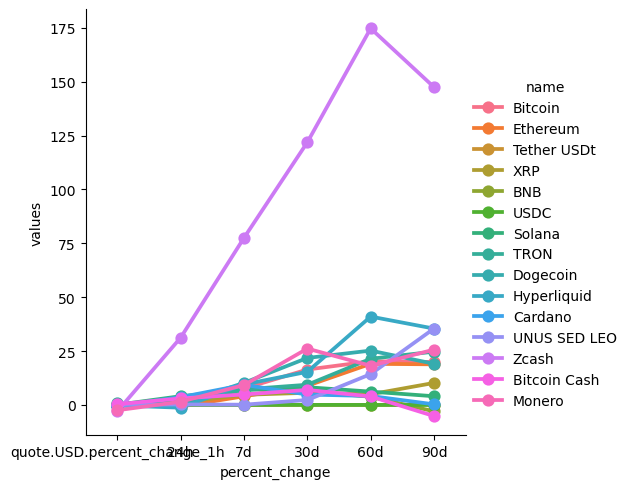

In [20]:
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point')

In [21]:
# create a dataframe with the columns we want

df10 = df[['name','quote.USD.price','timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp
0,Bitcoin,81555.03094,2026-05-06 12:40:14.438802


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

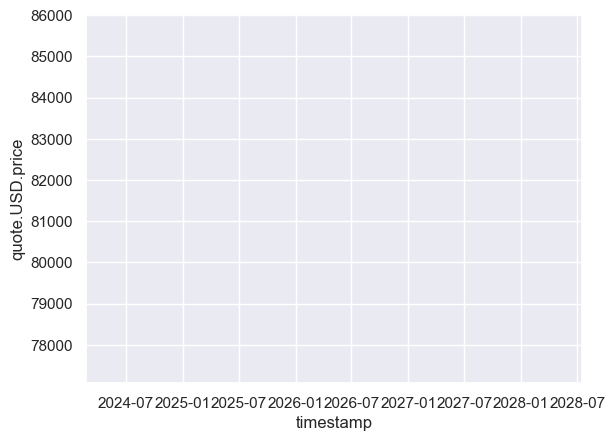

In [22]:
sns.set_theme(style="darkgrid")

sns.lineplot(x='timestamp', y='quote.USD.price', data = df10)